# Notebook 02 — Hypergraphuri

După ce ai învățat Julia în notebook 01, intrăm în **subiectul central** al stagiului: hypergraphurile.

**Parcurs:**
1. **De ce hypergraphuri?** Graphurile binare nu surprind tot — multe sisteme reale au relații "de ordin înalt".
2. **Definiții formale** — vocabular matematic (Berge 1973, Ouvrard 2020).
3. **HyperGraphs.jl** — pachetul Julia pentru construirea și manipularea lor.
4. **Aplicație în biochimie** — reproducem o rețea de fosforilare ca hypergraph, derivăm matricea de stoichiometrie automat (după Diaz & Stumpf 2022).

**Premise:** ai parcurs notebook 01. Avem Julia + Jupyter funcționale.

> 💡 Conceptele teoretice sunt prezentate **înainte** de cod. Asigură-te că vezi *de ce* avem nevoie de hypergraphuri înainte de *cum* le construiești.

## Cap. 3 — Teoria hypergraphurilor

### 3.1 De ce hypergraphuri? Limitele grafurilor binare

Un **graf clasic** $G = (V, E)$ are noduri (vârfuri) $V$ și muchii $E$, unde fiecare muchie leagă **exact două** noduri. E modelul standard pentru relații **binare**: prietenie între două persoane, legătură chimică între doi atomi, drum între două orașe.

Dar multe sisteme naturale au relații **de ordin înalt** — *trei sau mai multe* entități participă simultan la aceeași interacțiune. Câteva exemple:

| Domeniu | Relație de ordin înalt |
|---------|-----------------------|
| **Biochimie** | O reacție $A + B + C \rightarrow D + E$ implică simultan 5 specii. |
| **Proteomică** | Un **complex proteic** poate avea 4-10 subunități care interacționează împreună, nu doar perechi. |
| **Genomică** | Un **operon** bacterian e un grup de gene reglate simultan de același promotor. |
| **Rețele sociale** | Un autor publică un paper cu 5 co-autori — toți 6 sunt legați simultan. |
| **Chimie cuantică** | Un **unghi** de legătură implică 3 atomi; un **diedru**, 4 atomi. |

Forțând astfel de relații în grafuri binare pierzi informație. De aceea generalizăm.

**Hypergraph** = generalizare a grafului în care o **hyperedge** (muchie generalizată) poate lega **oricâte** vârfuri. Așa, $A + B + C \rightarrow D + E$ devine **o singură** hyperedge cu 5 vârfuri.

### 3.2 Definiție formală

Definiția standard, conform [Berge, 1973] și revizuită în [Ouvrard, 2020]:

Un **hypergraph** $\mathcal{H} = (V, E)$ constă din:
- o mulțime finită de **vârfuri** (noduri) $V = \{v_1, v_2, \ldots, v_n\}$;
- o mulțime de **hyperedges** $E = \{e_1, e_2, \ldots, e_p\}$, unde fiecare $e_j$ este o submulțime nevidă din $V$, adică $e_j \subseteq V$ și $e_j \neq \emptyset$.

**Cazul particular** $|e_j| = 2 \;\forall j$ recuperează un graf clasic. Adică un graf e *un hypergraph în care toate muchiile leagă fix 2 vârfuri*.

### Matricea de incidență

Reprezentarea matriceală a unui hypergraph e **matricea de incidență** $H \in \{0,1\}^{|V| \times |E|}$:

$$H_{ij} = \begin{cases} 1 & \text{dacă } v_i \in e_j \\ 0 & \text{altfel} \end{cases}$$

**Rândurile** sunt indexate de vârfuri, **coloanele** de hyperedges. La intersecție: 1 dacă vârful e în hyperedge.

Pentru chimie folosim o variantă **orientată** (cu semne): $H_{ij} = -1$ dacă specia $i$ e *reactant* în reacția $j$, $+1$ dacă e *produs*, $0$ altfel. Asta e exact **matricea de stoichiometrie**.

### 3.3 Tipuri particulare de hypergraphuri

Notații utile pentru a deosebi tipurile (după [Ouvrard, 2020], Sec. 2):

- **Simplu** — fără hyperedges repetate; nicio hyperedge nu e inclusă strict într-alta.
- **Linear** — simplu, și orice două hyperedges au cel mult **un vârf comun**.
- **Multi-hypergraph** — se permit hyperedges repetate (utile în chimie, pentru reacții cu coeficienți stoichiometrici).
- **Loop** — o hyperedge cu un singur vârf, $|e| = 1$.
- **Sub-hypergraph** $\mathcal{K}$ al lui $\mathcal{H}$ — submulțime de vârfuri și *toate* hyperedges-urile lui $\mathcal{H}$ care sunt incluse în această submulțime.
- **Partial hypergraph** — submulțime de hyperedges, păstrând toate vârfurile incidente.

În aplicațiile biochimice vom întâlni de obicei **multi-hypergraphs orientate ponderate** (rețele de reacții cu rate).

## Cap. 4 — HyperGraphs.jl

Pachet Julia [Diaz & Stumpf, 2022] proiectat pentru reprezentarea relațiilor de ordin înalt în sisteme biologice. Avantaje vs alternative (cum ar fi `SimpleHypergraphs.jl` sau `HyperNetX` pentru Python):
1. **Generalitate** — tipuri abstracte, ușor de extins.
2. **Compozabilitate** — funcționează cu `ModelingToolkit.jl`, `DifferentialEquations.jl` (ecosistemul SciML).
3. **Nativ orientat și ponderat** — `ChemicalHyperEdge` are intrări, ieșiri și rată, exact ca o reacție chimică.

### Instalare

Pachetul nu e (încă) în registry-ul General, deci instalăm direct din GitHub:

In [1]:
# Rulează o singură dată (idempotent — dacă e deja instalat, nu face nimic)
using Pkg
Pkg.add(url="https://github.com/lpmdiaz/HyperGraphs.jl")

    Updating git-repo `https://github.com/lpmdiaz/HyperGraphs.jl`


   Resolving package versions...


     Project No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Manifest.toml`


In [2]:
using HyperGraphs

### 4.1 HyperEdge — bloc de bază

Cea mai simplă hyperedge: o mulțime de vârfuri. În Julia, o construim cu `HyperEdge([v1, v2, ...])`.

Vârfurile pot fi *orice tip* — `Symbol` (cum vom folosi noi, ex `:a`, `:E`), `Int`, `String`, sau chiar tipuri proprii definite cu `struct`.

In [3]:
# Trei hyperedge-uri pe vârfuri abstracte
e1 = HyperEdge([:a, :b, :c])     # 3 vârfuri
e2 = HyperEdge([:b, :c, :d, :e]) # 4 vârfuri
e3 = HyperEdge([:a, :e])         # 2 vârfuri (ca o muchie clasică)

e1, e2, e3

(HyperEdge{Symbol}([:a, :b, :c]), HyperEdge{Symbol}([:b, :c, :d, :e]), HyperEdge{Symbol}([:a, :e]))

### 4.2 HyperGraph — colecția completă

Un `HyperGraph` se construiește dintr-un vector de hyperedges. Vârfurile sunt deduse automat din uniunea hyperedges-urilor.

In [4]:
G = HyperGraph([e1, e2, e3])

HyperGraph{Symbol}([:a, :b, :c, :d, :e], HyperEdge{Symbol}[HyperEdge{Symbol}([:a, :b, :c]), HyperEdge{Symbol}([:b, :c, :d, :e]), HyperEdge{Symbol}([:a, :e])])

### 4.3 Inspecția unui hypergraph

Funcții esențiale pentru a interoga structura (analoage cu API-ul `Graphs.jl`):

- `nv(G)` — numărul de vârfuri
- `nhe(G)` — numărul de hyperedges
- `vertices(G)` — vectorul de vârfuri
- `hyperedges(G)` — vectorul de hyperedges
- `incidence_matrix(G)` — matricea de incidență $H$

In [5]:
nv(G), nhe(G), vertices(G)

(5, 3, [:a, :b, :c, :d, :e])

In [6]:
incidence_matrix(G)

5×3 Matrix{Int64}:
 1  0  1
 1  1  0
 1  1  0
 0  1  0
 0  1  1

Citește rezultatul:
- **rândurile** = vârfurile, în ordinea din `vertices(G)` (adică `:a, :b, :c, :d, :e`)
- **coloanele** = cele 3 hyperedges (`e1, e2, e3`)
- $H_{ij} = 1$ ⇔ vârful $i$ aparține hyperedge-ului $j$

Verifică manual: `:a` ∈ `e1` și `:a` ∈ `e3`, dar `:a` ∉ `e2` ⇒ rândul lui `:a` e `[1, 0, 1]`.

## Cap. 5 — Aplicație: rețea de fosforilare ca hypergraph

### Context biochimic

**Fosforilarea** = atașarea unui grup fosfat ($PO_4^{3-}$) la o proteină, catalizată de o **kinază** ($E$). E unul dintre cele mai răspândite mecanisme de reglare post-traducțională — controlează semnalizarea celulară, ciclul celular, metabolismul. Este reversibilă: o **fosfatază** poate îndepărta grupul fosfat.

Schema clasică pentru fosforilarea dublă (două situri) a unui substrat $M$ de către kinaza $E$:

$$E + M \;\underset{k_2}{\overset{k_1}{\rightleftharpoons}}\; E_M \;\xrightarrow{k_3}\; pE + M$$

$$pE + M \;\underset{k_5}{\overset{k_4}{\rightleftharpoons}}\; pE_M \;\xrightarrow{k_6}\; ppE + M$$

Specii (5):
- $E$ — kinaza liberă
- $M$ — substrat (fără fosfat în context aici)
- $pE$ — kinaza mono-fosforilată
- $ppE$ — kinaza di-fosforilată (forma finală)
- $E_M$, $pE_M$ — complexe enzimă-substrat

Reacții (6 elementare).

**Întrebarea pedagogică:** cum scriem această rețea în Julia ca *o singură structură* de date din care putem deriva automat matricea de stoichiometrie? Răspuns: cu un `ChemicalHyperGraph`.

In [7]:
# Specii (Symbol = nume scurte, eficiente)
E, M, pE, ppE = :E, :M, :pE, :ppE
E_M, pE_M = :E_M, :pE_M

# Constante de viteză (tot Symbol — vom trata valorile numerice în notebook 03)
k1, k2, k3, k4, k5, k6 = :k1, :k2, :k3, :k4, :k5, :k6;

In [8]:
# Cele 6 reacții elementare ca ChemicalHyperEdge(reactanti, produsi, rata)
reactii = [
    ChemicalHyperEdge([E, M],   [E_M],     k1),   # 1. binding
    ChemicalHyperEdge([E_M],    [E, M],    k2),   # 2. unbinding
    ChemicalHyperEdge([E_M],    [pE, M],   k3),   # 3. fosforilare #1
    ChemicalHyperEdge([pE, M],  [pE_M],    k4),   # 4. binding
    ChemicalHyperEdge([pE_M],   [pE, M],   k5),   # 5. unbinding
    ChemicalHyperEdge([pE_M],   [ppE, M],  k6),   # 6. fosforilare #2
]

X = ChemicalHyperGraph(reactii)

ChemicalHyperGraph{Symbol}([:E, :M, :E_M, :pE, :pE_M, :ppE], ChemicalHyperEdge{Symbol}[ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:E, :M], [1, 1]), SpeciesSet{Symbol}([:E_M], [1]), :k1), ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:E_M], [1]), SpeciesSet{Symbol}([:E, :M], [1, 1]), :k2), ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:E_M], [1]), SpeciesSet{Symbol}([:pE, :M], [1, 1]), :k3), ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:pE, :M], [1, 1]), SpeciesSet{Symbol}([:pE_M], [1]), :k4), ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:pE_M], [1]), SpeciesSet{Symbol}([:pE, :M], [1, 1]), :k5), ChemicalHyperEdge{Symbol}(SpeciesSet{Symbol}([:pE_M], [1]), SpeciesSet{Symbol}([:ppE, :M], [1, 1]), :k6)])

In [9]:
# Inspecție structura
println("Specii (nv = $(nv(X))): ", vertices(X))
println("Reacții (nhe = $(nhe(X))):")
for (i, r) in enumerate(hyperedges(X))
    println("  $i: ", src(r), " → ", tgt(r), "   (rate = ", rate(r), ")")
end

Specii (nv = 6): [:E, :M, :E_M, :pE, :pE_M, :ppE]
Reacții (nhe = 6):
  1: [:E, :M] → [:E_M]   (rate = k1)
  2: [:E_M] → [:E, :M]   (rate = k2)
  3: [:E_M] → [:pE, :M]   (rate = k3)
  4: [:pE, :M] → [:pE_M]   (rate = k4)
  5: [:pE_M] → [:pE, :M]   (rate = k5)
  6: [:pE_M] → [:ppE, :M]   (rate = k6)


### 🎨 Vizualizare grafică a rețelei

Înainte de a calcula matricea de stoichiometrie, **hai să vedem cum arată hypergraph-ul**! Definim o funcție generală `plot_hypergraph` care plasează vârfurile pe un cerc și desenează fiecare hyperedge ca un poligon colorat translucid peste vârfurile pe care le acoperă.

Funcția merge atât pentru `HyperGraph` (unsigned) cât și pentru `ChemicalHyperGraph` (cu direcție — pentru viz îi tratăm vârfurile fără direcție, doar structura).

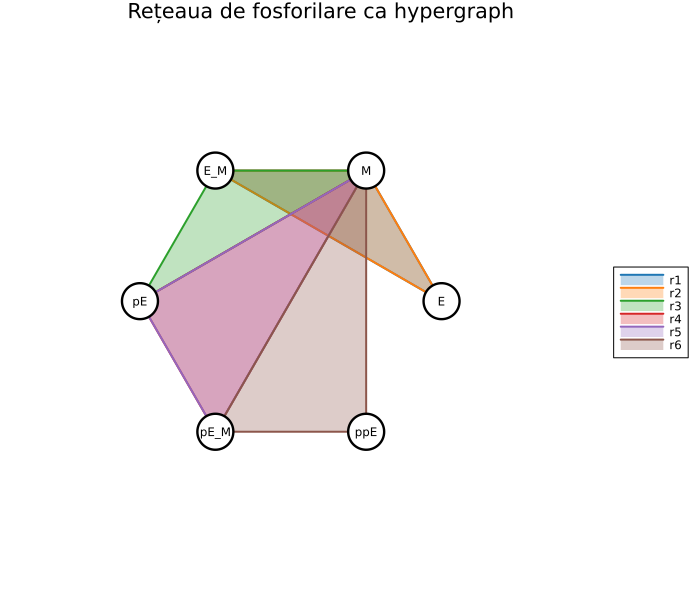

In [10]:
using Plots
using Statistics: mean

function plot_hypergraph(G; edge_alpha=0.3, size=(700, 600), title="Hypergraph")
    verts = vertices(G)
    n = length(verts)
    edges = hyperedges(G)

    angles = range(0, 2π; length=n+1)[1:n]
    pos = Dict(verts[i] => (cos(angles[i]), sin(angles[i])) for i in 1:n)

    plt = plot(aspect_ratio=:equal, legend=:outerright, grid=false,
               framestyle=:none, size=size, title=title,
               xlims=(-1.6, 2.0), ylims=(-1.5, 1.5))

    # vertices of an edge (works for both HyperEdge and ChemicalHyperEdge)
    edge_vset(e) = e isa ChemicalHyperEdge ? unique(vcat(src(e), tgt(e))) : vertices(e)

    cs = palette(:tab10)
    for (j, e) in enumerate(edges)
        pts = [pos[v] for v in edge_vset(e)]
        c = cs[mod1(j, length(cs))]
        lbl = e isa ChemicalHyperEdge ? "r$j" : "e$j"

        if length(pts) == 1
            scatter!(plt, [pts[1][1]], [pts[1][2]], ms=40, color=c,
                     alpha=edge_alpha, markerstrokewidth=0, label=lbl)
        elseif length(pts) == 2
            plot!(plt, [pts[1][1], pts[2][1]], [pts[1][2], pts[2][2]],
                  color=c, lw=20, alpha=edge_alpha, label=lbl)
        else
            xs = [p[1] for p in pts]; ys = [p[2] for p in pts]
            cx, cy = mean(xs), mean(ys)
            order = sortperm([atan(y-cy, x-cx) for (x, y) in zip(xs, ys)])
            xs_s = vcat(xs[order], xs[order[1]])
            ys_s = vcat(ys[order], ys[order[1]])
            plot!(plt, xs_s, ys_s, fill=(0, edge_alpha, c), color=c, lw=2, label=lbl)
        end
    end

    for v in verts
        scatter!(plt, [pos[v][1]], [pos[v][2]], color=:white, ms=20,
                 markerstrokewidth=2, markerstrokecolor=:black, label=false)
        annotate!(plt, pos[v][1], pos[v][2], text(string(v), 8, :center))
    end
    return plt
end

plot_hypergraph(X; title="Rețeaua de fosforilare ca hypergraph")

### 5.1 Matricea de stoichiometrie — derivată automat

Aici se vede puterea reprezentării ca hypergraph: matricea de stoichiometrie iese **gratuit** din `incidence_matrix(X)`. Convenția semnelor:
- **$-1$** ⇒ specie consumată (reactant)
- **$+1$** ⇒ specie produsă (produs)
- **$0$** ⇒ specie neimplicată în reacție

In [11]:
S = incidence_matrix(X)

6×6 Matrix{Int64}:
 -1   1   0   0   0   0
 -1   1   1  -1   1   1
  1  -1  -1   0   0   0
  0   0   1  -1   1   0
  0   0   0   1  -1  -1
  0   0   0   0   0   1

In [12]:
# Afisare tabel: rinduri = specii, coloane = reactii
println("            r1   r2   r3   r4   r5   r6")
for (i, sp) in enumerate(vertices(X))
    print(rpad(string(sp), 8))
    for j in 1:nhe(X)
        print(lpad(string(S[i,j]), 5))
    end
    println()
end

            r1   r2   r3   r4   r5   r6
E          -1    1    0    0    0    0
M          -1    1    1   -1    1    1
E_M         1   -1   -1    0    0    0
pE          0    0    1   -1    1    0
pE_M        0    0    0    1   -1   -1
ppE         0    0    0    0    0    1


**🎨 Aceeași matrice ca heatmap** — mai ușor de citit vizual:

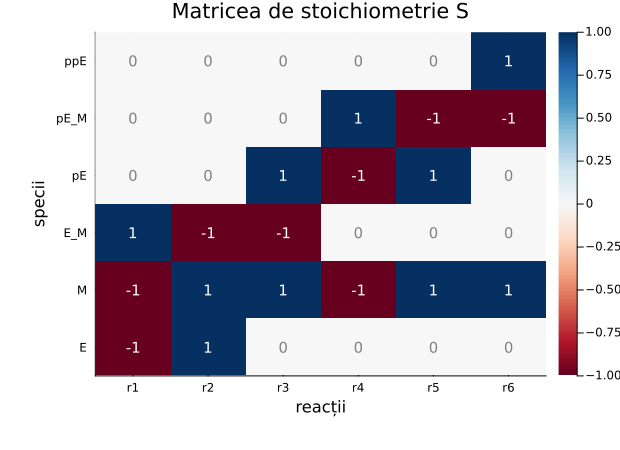

In [13]:
p_heat = heatmap(S, c=:RdBu, clim=(-1, 1),
                 xlabel="reacții", ylabel="specii",
                 xticks=(1:nhe(X), ["r$j" for j in 1:nhe(X)]),
                 yticks=(1:nv(X), string.(vertices(X))),
                 title="Matricea de stoichiometrie S",
                 size=(620, 450),
                 left_margin=8Plots.mm, bottom_margin=8Plots.mm)
for i in 1:size(S,1), j in 1:size(S,2)
    annotate!(p_heat, j, i, text(string(S[i,j]), 10, S[i,j] == 0 ? :gray : :white))
end
p_heat

### 5.2 Citirea fizico-chimică a matricei

Reacția 1 ($E + M \rightarrow E_M$): coloana 1 a matricei e `[-1, -1, 1, 0, 0, 0]`. Asta înseamnă:
- $E$ consumat (–1) ✓
- $M$ consumat (–1) ✓
- $E_M$ produs (+1) ✓
- $pE, ppE, pE_M$ neafectate ✓

Reacția 3 ($E_M \rightarrow pE + M$): coloana 3 e `[0, 1, -1, 1, 0, 0]`:
- $E_M$ consumat (–1)
- $pE$ produs (+1)
- $M$ recuperat (+1)

Matricea **este** reprezentarea computabilă a întregii rețele. De aici încolo:
- combinațiile liniare ale coloanelor → calea posibilă de la o stare la alta;
- nucleul stâng al $S$ → **legile de conservare** (cantități care nu se schimbă);
- $\frac{d\vec{c}}{dt} = S \vec{v}(\vec{c})$, unde $\vec{v}$ sunt vitezele de reacție → **sistemul de ODE**.

Ultima formulă e ce face `ModelingToolkit.jl` automat, plecând de la `ChemicalHyperGraph`. Vom intra în detaliu în notebook 03.

### 5.3 Verificare: legile de conservare

Pentru sistemul nostru, prin construcție, există două cantități conservate:
1. **Kinaza totală:** $[E] + [E_M] + [pE] + [pE_M] + [ppE] = \text{const}$. Toate formele kinazei.
2. **Substratul total:** $[M] + [E_M] + [pE_M] = \text{const}$.

Dacă alegem **vectorii de conservare** ca vectori-rânduri, atunci înmulțirea lor cu matricea $S$ trebuie să dea **zero** (deci nu se schimbă în nicio reacție).

In [14]:
# Indici specii in ordinea din vertices(X)
ord = vertices(X)
println("Ordine specii: ", ord)

# Vector de conservare pentru kinaza totala: 1 pe E, pE, ppE, E_M, pE_M; 0 pe M
cons_kinaza = [sp in (:E, :pE, :ppE, :E_M, :pE_M) ? 1 : 0 for sp in ord]

# Vector de conservare pentru substrat total: 1 pe M, E_M, pE_M; 0 altfel
cons_substrat = [sp in (:M, :E_M, :pE_M) ? 1 : 0 for sp in ord]

println("cons_kinaza   = ", cons_kinaza)
println("cons_substrat = ", cons_substrat)

Ordine specii: [:E, :M, :E_M, :pE, :pE_M, :ppE]
cons_kinaza   = 

[1, 0, 1, 1, 1, 1]
cons_substrat = [0, 1, 1, 0, 1, 0]


In [15]:
# Daca vectorii sunt valizi, inmultirea lor cu S da vectorul zero
println("cons_kinaza' * S   = ", cons_kinaza' * S)
println("cons_substrat' * S = ", cons_substrat' * S)

cons_kinaza' * S   = adjoint([0, 0, 0, 0, 0, 0])
cons_substrat' * S = adjoint([0, 0, 0, 0, 0, 0])


Ambele produse sunt zero pe toate reacțiile ⇒ cele două cantități **se conservă** în toată dinamica sistemului. Asta e o consecință directă a structurii hypergraphului — n-am avut nevoie să scriem ODE-uri.

### 5.4 De la hypergraph la ODE — simulare dinamică

Reprezentarea ca hypergraph nu e doar contabilitate — e **sursa de adevăr** din care derivăm întreaga *dinamică* a sistemului. Câteva linii de cod transformă $\mathcal{H}$ într-un sistem de ecuații diferențiale rezolvabil numeric.

**Cinetica de acțiune a maselor.** Pentru fiecare reacție elementară $j$ cu reactanți de coeficienți $|s_{ij}|$:

$$v_j(\vec{c}) = k_j \prod_{i \,:\, s_{ij} < 0} c_i^{|s_{ij}|}$$

La noi toți coeficienții sunt 1, deci $v_j = k_j \prod_i c_i$ (produsul concentrațiilor reactantilor).

**Sistemul de ODE.** Cu $S$ = matricea de stoichiometrie și $\vec{v}$ = vectorul de viteze:

$$\frac{d\vec{c}}{dt} = S\,\vec{v}(\vec{c})$$

Asta este. Toate ODE-urile rețelei într-o singură formulă matriceală. Pentru rezolvare numerică folosim `OrdinaryDiffEq.jl` (din ecosistemul SciML) cu solverul **Tsit5** — un Runge-Kutta de ordin 5 [Tsitouras, 2011], rapid și precis pentru ODE-uri non-stiff. Pentru vizualizare: `Plots.jl`.

**Pasul 1 — instalare (o singură dată).** Pachetele OrdinaryDiffEq + Plots sunt grele (mai ales prima precompilare poate dura câteva minute). Mergi pune un ceai.

In [16]:
using Pkg
Pkg.add(["OrdinaryDiffEq", "Plots"])

   Resolving package versions...


     Project No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Manifest.toml`


In [17]:
using OrdinaryDiffEq, Plots

**Pasul 2 — valori numerice pentru constantele de viteză.** Până acum am folosit Symbol-uri abstracte (`:k1`, `:k2`, ...) — utile pentru reprezentarea structurală. Pentru simulare numerică le mapăm la valori float.

Valorile alese mai jos sunt **plausibile biologic** (binding rapid, fosforilare mai lent) și produc o dinamică interesantă pe scala de timp 0–50 unități arbitrare.

In [18]:
k_vals = Dict(
    :k1 => 1.0,   :k2 => 0.1,   :k3 => 0.5,
    :k4 => 1.0,   :k5 => 0.1,   :k6 => 0.5,
)

Dict{Symbol, Float64} with 6 entries:
  :k6 => 0.5
  :k5 => 0.1
  :k1 => 1.0
  :k2 => 0.1
  :k3 => 0.5
  :k4 => 1.0

**Pasul 3 — funcția vitezelor $\vec{v}(\vec{c})$.** Pentru fiecare reacție iterăm peste reactanti și multiplicăm.

`sp_idx` mapează fiecare specie la poziția ei în vectorul de stare `u`.

In [19]:
# Mapeaza fiecare specie la indexul ei in vectorul u
sp_idx = Dict(sp => i for (i, sp) in enumerate(vertices(X)))

function rates(u, X, k_vals, sp_idx)
    v = zeros(nhe(X))
    for (j, e) in enumerate(hyperedges(X))
        r = k_vals[rate(e)]
        for sp in src(e)
            r *= u[sp_idx[sp]]
        end
        v[j] = r
    end
    return v
end

rates (generic function with 1 method)

**Pasul 4 — funcția ODE și condițiile inițiale.**

`OrdinaryDiffEq` cere o funcție `f!(du, u, p, t)` care modifică `du` *in-place* (convenția standard pentru performanță). Aplicăm formula $\frac{d\vec{c}}{dt} = S\,\vec{v}$.

Condiții inițiale: pornim cu **1 unitate de kinază E** și **5 unități de substrat M**, toți complecșii și formele fosforilate la 0.

In [20]:
function f!(du, u, p, t)
    X_, k_vals_, sp_idx_, S_ = p
    v = rates(u, X_, k_vals_, sp_idx_)
    du .= S_ * v
    return nothing
end

# Conditii initiale
u0 = zeros(nv(X))
u0[sp_idx[:E]] = 1.0
u0[sp_idx[:M]] = 5.0

# Setup problema
tspan = (0.0, 50.0)
p = (X, k_vals, sp_idx, S)
prob = ODEProblem(f!, u0, tspan, p)

# Rezolvare
sol = solve(prob, Tsit5())
println("Stare finala (t = $(sol.t[end])):")
for sp in vertices(X)
    println("  $sp = ", round(sol.u[end][sp_idx[sp]]; digits=4))
end

Stare finala (t = 50.0):


  E = 0.0
  M = 5.0
  E_M = -0.0
  pE = 0.0
  pE_M = -0.0
  ppE = 1.0


**Pasul 5 — vizualizare.** `Plots.jl` are o *recipe* dedicată pentru soluțiile ODE: trasează automat toate componentele lui `u` în funcție de timp.

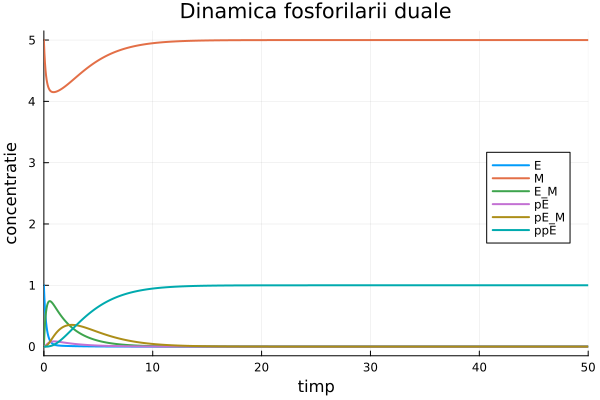

In [21]:
plot(sol,
    labels = permutedims(string.(vertices(X))),
    xlabel = "timp",
    ylabel = "concentratie",
    title  = "Dinamica fosforilarii duale",
    lw = 2,
    legend = :right)

**Interpretarea graficului:**
- $E$ (kinaza liberă) — scade rapid la 0, formează complexe cu substratul;
- $M$ (substratul) — *catalist efectiv*: scade când e prins în complex, apoi se eliberează după fiecare fosforilare; la final revine aproape la valoarea inițială (5);
- $E_M$ și $pE_M$ — intermediari tranzitori, ating un maxim apoi descresc;
- $pE$ — kinaza mono-fosforilată, formă tranzitoare; atinge un maxim moderat și e ulterior consumată pentru a forma $ppE$;
- $ppE$ — kinaza di-fosforilată, **produsul final stabil**; crește monoton spre 1 (toată kinaza e fosforilată complet).

Sistemul atinge un *steady state* în care întreaga kinază e în formă $ppE$. Asta e tipic pentru cascade ireversibile (în absența fosfatazei — pe care o vom adăuga ca exercițiu).

**Verificare numerică a legilor de conservare** (am derivat algebric mai sus că trebuie să se păstreze; acum confirmăm și în soluția numerică):

In [22]:
# Conservare verificata numeric
E_total_final = sum(sol.u[end][sp_idx[s]] for s in (:E, :pE, :ppE, :E_M, :pE_M))
M_total_final = sum(sol.u[end][sp_idx[s]] for s in (:M, :E_M, :pE_M))
println("E_total final = ", round(E_total_final; digits=6), "  (initial 1.0)")
println("M_total final = ", round(M_total_final; digits=6), "  (initial 5.0)")

E_total final = 1.0  (initial 1.0)
M_total final = 5.0  (initial 5.0)


### 5.5 De la cod manual la ModelingToolkit

Codul de mai sus a fost foarte transparent — vezi exact formula $dc/dt = S\,v$. Pentru rețele cu sute de reacții, însă, scrierea manuală a funcției `rates` devine impractică. Aici intră **`ModelingToolkit.jl`** [Ma et al., 2021], parte din ecosistemul SciML:

- Reprezintă simbolic ecuațiile;
- **Optimizează automat** codul rezultat (common subexpression elimination, sparse Jacobian, paralelizare);
- Cuplat cu `HyperGraphs.jl`, pipeline-ul `ChemicalHyperGraph → mass_action → ODESystem → solve` se scrie în ~10 linii (vezi [Diaz & Stumpf, 2022], Appendix A.2).

Vom intra în detaliu pe `ModelingToolkit` în **notebook 03**, unde stack-ul SciML va fi unealta de bază pentru a combina simulări mecaniciste cu modele ML pentru proteine.

## Exerciții

Soluțiile sunt mai jos — încearcă întâi singură.

### Exercițiul 1 — Hypergraph non-chimic

Modelează grupul de prieteni Anna, Bogdan, Cris, Dana, Elena. Au mers împreună la:
- excursie la mare: Anna, Bogdan, Cris
- concert: Bogdan, Cris, Dana, Elena
- film: Anna, Elena

Construiește hypergraph-ul (vârfurile = persoane, hyperedges = activități). Afișează matricea de incidență. Care e persoana cea mai activă (apare în cele mai multe activități)?

*Hint:* după ce ai matricea, suma pe rând îți spune câte activități a făcut fiecare persoană (`sum(M_inc; dims=2)`).

In [23]:
# Scrie aici solutia ta — Exercitiul 1


### Exercițiul 2 — Combustia metanului

Modelează reacția simplificată $CH_4 + 2O_2 \rightarrow CO_2 + 2H_2O$ ca un `ChemicalHyperEdge` într-un `ChemicalHyperGraph`. Inspectează `src`, `tgt`, `rate` și `incidence_matrix`.

*Hint:* coeficienții stoichiometrici (`2` în fața lui $O_2$ și $H_2O$) se reprezintă **repetând** specia în lista de inputs/outputs: `[O2, O2]` în loc de `[O2]`.

In [24]:
# Scrie aici solutia ta — Exercitiul 2


### Exercițiul 3 — Extensie cu defosforilare

Schema de mai sus modelează doar fosforilarea (forward). Adaugă fosfataza $Pt$ care îndepărtează grupurile fosfat:

$$ppE + Pt \;\underset{k'_2}{\overset{k'_1}{\rightleftharpoons}}\; ppE_{Pt} \;\xrightarrow{k'_3}\; pE + Pt$$
$$pE + Pt \;\underset{k'_5}{\overset{k'_4}{\rightleftharpoons}}\; pE_{Pt} \;\xrightarrow{k'_6}\; E + Pt$$

Adaugă cele 6 reacții suplimentare la rețeaua existentă. Specii noi: $Pt$, $pE_{Pt}$, $ppE_{Pt}$. Câte specii și reacții are sistemul complet? Verifică conservarea **fosfatazei totale** ($Pt + pE_{Pt} + ppE_{Pt} = \text{const}$).

*Hint:* construiești reacțiile noi ca `ChemicalHyperEdge` și le adaugi la lista existentă, apoi reconstruiești `ChemicalHyperGraph`.

In [25]:
# Scrie aici solutia ta — Exercitiul 3


## Soluții

*Nu citi înainte să fi încercat singură.*

In [26]:
# Solutia 1 — grup de prieteni
activitati = [
    HyperEdge([:Anna, :Bogdan, :Cris]),
    HyperEdge([:Bogdan, :Cris, :Dana, :Elena]),
    HyperEdge([:Anna, :Elena]),
]
Gp = HyperGraph(activitati)
println("Persoane: ", vertices(Gp))
M_act = incidence_matrix(Gp)
println("Matricea de incidență:")
display(M_act)

activ_per_persoana = sum(M_act; dims=2)
println("\nActivități per persoană:")
for (i, p) in enumerate(vertices(Gp))
    println("  $p: $(activ_per_persoana[i])")
end

Persoane: [:Anna, :Bogdan, :Cris, :Dana, :Elena]


Matricea de incidență:


5×3 Matrix{Int64}:
 1  0  1
 1  1  0
 1  1  0
 0  1  0
 0  1  1


Activități per persoană:


  Anna: 2
  Bogdan: 2
  Cris: 2
  Dana: 1
  Elena: 2


In [27]:
# Solutia 2 — combustia metanului
CH4_, O2_, CO2_, H2O_ = :CH4, :O2, :CO2, :H2O
k_comb = :k_comb

# Coeficientii stoichiometrici prin repetare
reactia_comb = ChemicalHyperEdge(
    [CH4_, O2_, O2_],          # 1 CH4 + 2 O2
    [CO2_, H2O_, H2O_],        # 1 CO2 + 2 H2O
    k_comb
)

Xc = ChemicalHyperGraph([reactia_comb])
println("Specii: ", vertices(Xc))
println("src: ", src(reactia_comb))
println("tgt: ", tgt(reactia_comb))
println("Matricea de incidență (= stoichiometria):")
display(incidence_matrix(Xc))

Specii: [:CH4, :O2, :CO2, :H2O]
src: [:CH4, :O2, :O2]
tgt: [:CO2, :H2O, :H2O]
Matricea de incidență (= stoichiometria):


4×1 Matrix{Int64}:
 -1
 -2
  1
  2

In [28]:
# Solutia 3 — extensie cu defosforilare
Pt = :Pt
pE_Pt, ppE_Pt = :pE_Pt, :ppE_Pt
kp1, kp2, kp3, kp4, kp5, kp6 = :kp1, :kp2, :kp3, :kp4, :kp5, :kp6

reactii_deph = [
    ChemicalHyperEdge([ppE, Pt],    [ppE_Pt],    kp1),
    ChemicalHyperEdge([ppE_Pt],     [ppE, Pt],   kp2),
    ChemicalHyperEdge([ppE_Pt],     [pE, Pt],    kp3),
    ChemicalHyperEdge([pE, Pt],     [pE_Pt],     kp4),
    ChemicalHyperEdge([pE_Pt],      [pE, Pt],    kp5),
    ChemicalHyperEdge([pE_Pt],      [E, Pt],     kp6),
]

X_full = ChemicalHyperGraph(vcat(reactii, reactii_deph))
println("Specii (nv = $(nv(X_full))): ", vertices(X_full))
println("Reactii (nhe = $(nhe(X_full)))")

S_full = incidence_matrix(X_full)
ord_full = vertices(X_full)
cons_Pt = [sp in (:Pt, :pE_Pt, :ppE_Pt) ? 1 : 0 for sp in ord_full]
println("\nVerificare conservare Pt total:")
println("  cons_Pt' * S = ", cons_Pt' * S_full)
println("  (tot zero ⇒ Pt total se conservă ✓)")

Specii (nv = 9): [:E, :M, :E_M, :pE, :pE_M, :ppE, :Pt, :ppE_Pt, :pE_Pt]
Reactii (nhe = 12)

Verificare conservare Pt total:


  cons_Pt' * S = adjoint([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
  (tot zero ⇒ Pt total se conservă ✓)


## Ce ai învățat în acest notebook

- ✅ **De ce hypergraphuri** — limita relațiilor binare, exemple de relații de ordin înalt în chimie/biologie/sociologie.
- ✅ **Definiție formală** $\mathcal{H} = (V, E)$ și matricea de incidență.
- ✅ **Tipuri particulare** — simplu, linear, multi, loop, sub-hypergraph, partial.
- ✅ **HyperGraphs.jl** — `HyperEdge`, `HyperGraph`, `ChemicalHyperEdge`, `ChemicalHyperGraph`.
- ✅ Inspecția: `nv`, `nhe`, `vertices`, `hyperedges`, `incidence_matrix`, `src`, `tgt`, `rate`.
- ✅ Aplicație: o **rețea de fosforilare** ca hypergraph — matricea de stoichiometrie iese automat.
- ✅ **Legile de conservare** verificate algebric direct din $S$.

**Următor pas:** notebook 03, în care:
- folosim `ChemicalHyperGraph` ca sursă de adevăr pentru o simulare ODE (cu `ModelingToolkit.jl` + `OrdinaryDiffEq.jl`);
- introducem **Hypergraph Neural Networks** [Feng et al., 2019];
- discutăm aplicații în ML pentru proteine — predicție de funcție, interfețe, design *de novo*.

## Referințe

**Teoria hypergraphurilor:**
- **Berge, C. (1973).** *Graphs and Hypergraphs*. North-Holland Publishing Company. (cartea fondatoare)
- **Ouvrard, X. (2020).** Hypergraphs: an introduction and review. *arXiv preprint*. [arXiv:2002.05014](https://arxiv.org/abs/2002.05014)
- **Bretto, A. (2013).** *Hypergraph Theory: An Introduction*. Springer. [DOI: 10.1007/978-3-319-00080-0](https://doi.org/10.1007/978-3-319-00080-0)

**Pachetul Julia:**
- **Diaz, L. P. M., & Stumpf, M. P. H. (2022).** HyperGraphs.jl: representing higher-order relationships in Julia. *Bioinformatics*, 38(15), 3795–3797. [DOI: 10.1093/bioinformatics/btac347](https://doi.org/10.1093/bioinformatics/btac347)
- HyperGraphs.jl repository — <https://github.com/lpmdiaz/HyperGraphs.jl>

**Alternative:**
- SimpleHypergraphs.jl (Antelmi et al., 2020) — <https://github.com/pszufe/SimpleHypergraphs.jl>
- HyperNetX (PNNL, Python) — <https://github.com/pnnl/HyperNetX>